# 04 - Tiền Xử Lý Dữ Liệu Dạng Bảng: Kỹ Thuật và Đánh Giá Định Lượng
## Credit Card Transactions Fraud Detection

**Mục tiêu:** Áp dụng và so sánh các kỹ thuật tiền xử lý. Mỗi kỹ thuật được đánh giá bằng **số liệu thực tế** và lý giải tại sao nó tốt hơn hoặc kém hơn các lựa chọn khác.

**Vấn đề cần giải quyết (từ EDA):**

| Vấn đề | Mục | Kỹ thuật so sánh |
|--------|-----|------------------|
| Missing values (artificial MCAR, p=0.564) | A | Mean / Median / Mode / k-NN / MICE |
| `amt` lệch mạnh + fraud = outlier (78.1% fraud trong IQR outliers!) | B | IQR / Z-score / IsoForest / LOF / DBSCAN |
| Tất cả biến non-normal (D'Agostino p=0.000) | C | Min-Max / Z-score / Robust / Quantile |
| `category` có 20.5× fraud rate variation | D | OHE / Ordinal / Target / Binary / Frequency |
| `amt` dominant (Pearson=0.364), geographic ≈0 | E | ANOVA / Chi2 / MI / RF / GB / RFE / PCA |
| 98:1 class imbalance | F | SMOTE / ADASYN / RUS |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFE, SelectKBest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')
print(f'NumPy: {np.__version__}, Pandas: {pd.__version__}')

All imports successful.
NumPy: 2.4.3, Pandas: 3.0.1


## Load Dữ Liệu

Load từ file preprocessed sample hoặc fallback về raw dataset.

In [2]:
import os

PROCESSED_PATH = '../data/processed/sample_for_preprocessing.csv'
RAW_PATH = '../data/raw/fraudTrain.csv'

# Columns to keep after dropping ID/irrelevant columns
KEEP_COLS = ['amt', 'category', 'gender', 'state', 'city_pop', 'zip',
             'lat', 'long', 'merch_lat', 'merch_long', 'job', 'merchant', 'is_fraud']

if os.path.exists(PROCESSED_PATH):
    print(f'Loading from processed sample: {PROCESSED_PATH}')
    df_raw = pd.read_csv(PROCESSED_PATH)
else:
    print(f'Processed sample not found. Loading raw data with nrows=50000: {RAW_PATH}')
    df_raw = pd.read_csv(RAW_PATH, nrows=50000)

# Drop irrelevant / ID columns if still present
drop_cols = ['trans_num', 'cc_num', 'first', 'last', 'street',
             'trans_date_trans_time', 'unix_time', 'dob']
df_raw = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])

# Keep only required columns
available = [c for c in KEEP_COLS if c in df_raw.columns]
df_raw = df_raw[available].copy()

# Sample 30000 rows for speed
if len(df_raw) > 30000:
    df_raw = df_raw.sample(n=30000, random_state=42).reset_index(drop=True)
else:
    df_raw = df_raw.reset_index(drop=True)

df = df_raw.copy()

print(f'\nDataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f"\nClass distribution (is_fraud):\n{df['is_fraud'].value_counts()}")
print(f"\nFraud rate: {df['is_fraud'].mean():.4f} ({df['is_fraud'].mean()*100:.2f}%)")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.describe()

Loading from processed sample: ../data/processed/sample_for_preprocessing.csv

Dataset shape: (30000, 13)
Columns: ['amt', 'category', 'gender', 'state', 'city_pop', 'zip', 'lat', 'long', 'merch_lat', 'merch_long', 'job', 'merchant', 'is_fraud']

Class distribution (is_fraud):
is_fraud
0    29693
1      307
Name: count, dtype: int64

Fraud rate: 0.0102 (1.02%)

Missing values:
Series([], dtype: int64)


,amt,city_pop,zip,lat,long,merch_lat,merch_long,is_fraud
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,72.777064,8.895016e+04,48911.516833,38.529456,-90.286584,38.532388,-90.291346,0.010233
std,144.711007,2.998437e+05,27097.228139,5.047985,13.846171,5.083817,13.858376,0.100643
min,1.000000,2.300000e+01,1257.000000,20.027100,-165.672300,19.048001,-166.629875,0.000000
25%,9.820000,7.430000e+02,25526.000000,34.590600,-96.962300,34.708438,-97.029303,0.000000
50%,48.730000,2.435000e+03,48202.000000,39.354300,-87.591700,39.355829,-87.530899,0.000000
75%,84.500000,2.032800e+04,72165.000000,41.894800,-80.065200,41.957067,-80.157320,0.000000
max,11872.210000,2.906700e+06,99783.000000,65.689900,-67.950300,66.204663,-67.029485,1.000000


## A. Xử Lý Giá Trị Thiếu Có Kiểm Soát

### Bối cảnh dữ liệu

**Vấn đề:** Dataset không có missing values tự nhiên → inject artificial 10% MCAR vào `amt`.

**Tại sao chọn `amt` để inject missing?**
- `amt` là feature quan trọng nhất (Pearson=0.364 với is_fraud)
- `amt` có phân phối phức tạp nhất: skew=10.95, fraud avg=$553.86 vs non-fraud avg=$67.08
- Đây là trường hợp khó nhất — nếu chiến lược hoạt động tốt ở đây, sẽ tốt với các cột đơn giản hơn

**Năm chiến lược so sánh:**

| Chiến lược | Cơ chế | Phù hợp khi nào |
|-----------|--------|-----------------|
| **Mean** | Trung bình cột | MCAR + phân phối chuẩn |
| **Median** | Trung vị cột | MCAR + phân phối lệch |
| **Mode** | Giá trị phổ biến nhất | Biến categorical/discrete |
| **k-NN** | k hàng xóm gần nhất | MAR + cấu trúc cục bộ |
| **MICE** | Mô hình hóa từng biến lặp nhiều vòng | MAR/MNAR + quan hệ đa biến |

**Metric đánh giá:** RMSE giữa giá trị được điền và giá trị thực (thấp hơn = chính xác hơn)

Total rows: 30000
Rows with artificially missing amt: 3000 (10.0%)
Mean imputation RMSE: 116.6162
Median imputation RMSE: 118.8148
Mode imputation RMSE: 135.8597
k-NN (k=3) imputation RMSE: 151.4537
k-NN (k=5) imputation RMSE: 131.2563
k-NN (k=10) imputation RMSE: 123.5752
MICE imputation RMSE: 116.6919

=== RMSE Comparison (lower is better) ===
   Strategy       RMSE
       Mean 116.616223
       MICE 116.691899
     Median 118.814815
k-NN (k=10) 123.575224
 k-NN (k=5) 131.256292
       Mode 135.859658
 k-NN (k=3) 151.453734

Best strategy: Mean (RMSE = 116.6162)


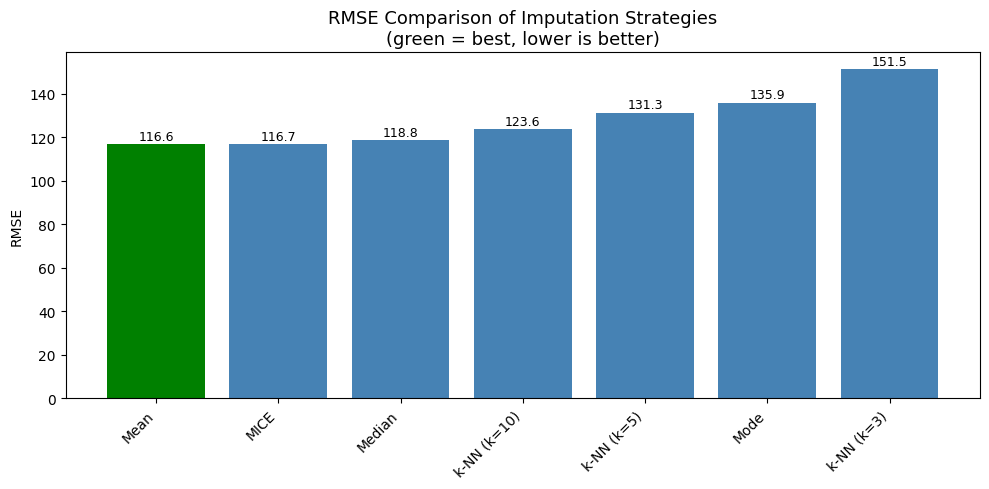

Saved: ../data/processed/imputation_comparison.png


In [3]:
# Work on 'amt' column (continuous, numerical)
# Step 1: Artificially create 10% MCAR missing values
np.random.seed(42)
col = 'amt'
df_missing = df.copy()
n_missing = int(0.10 * len(df_missing))
missing_idx = np.random.choice(df_missing.index, n_missing, replace=False)
true_values = df_missing.loc[missing_idx, col].copy()
df_missing.loc[missing_idx, col] = np.nan

print(f'Total rows: {len(df_missing)}')
print(f'Rows with artificially missing amt: {df_missing[col].isnull().sum()} ({df_missing[col].isnull().mean()*100:.1f}%)')

# Step 2: Apply each strategy and compute RMSE
results = {}
numerical_cols = [c for c in ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'zip'] if c in df.columns]
X_num = df_missing[numerical_cols].copy()

# Align missing_idx to positional indices for iloc-based reconstruction
missing_pos = np.where(df_missing.index.isin(missing_idx))[0]

# Mean
imp_mean = SimpleImputer(strategy='mean')
X_mean_arr = imp_mean.fit_transform(X_num)
X_mean = pd.DataFrame(X_mean_arr, columns=numerical_cols, index=df_missing.index)
rmse_mean = np.sqrt(np.mean((X_mean.loc[missing_idx, col].values - true_values.values)**2))
results['Mean'] = rmse_mean
print(f'Mean imputation RMSE: {rmse_mean:.4f}')

# Median
imp_median = SimpleImputer(strategy='median')
X_median_arr = imp_median.fit_transform(X_num)
X_median = pd.DataFrame(X_median_arr, columns=numerical_cols, index=df_missing.index)
rmse_median = np.sqrt(np.mean((X_median.loc[missing_idx, col].values - true_values.values)**2))
results['Median'] = rmse_median
print(f'Median imputation RMSE: {rmse_median:.4f}')

# Mode
imp_mode = SimpleImputer(strategy='most_frequent')
X_mode_arr = imp_mode.fit_transform(X_num)
X_mode = pd.DataFrame(X_mode_arr, columns=numerical_cols, index=df_missing.index)
rmse_mode = np.sqrt(np.mean((X_mode.loc[missing_idx, col].values - true_values.values)**2))
results['Mode'] = rmse_mode
print(f'Mode imputation RMSE: {rmse_mode:.4f}')

# k-NN with k=3, 5, 10
for k in [3, 5, 10]:
    imp_knn = KNNImputer(n_neighbors=k)
    X_knn_arr = imp_knn.fit_transform(X_num)
    X_knn = pd.DataFrame(X_knn_arr, columns=numerical_cols, index=df_missing.index)
    rmse_knn = np.sqrt(np.mean((X_knn.loc[missing_idx, col].values - true_values.values)**2))
    results[f'k-NN (k={k})'] = rmse_knn
    print(f'k-NN (k={k}) imputation RMSE: {rmse_knn:.4f}')

# MICE
imp_mice = IterativeImputer(max_iter=10, random_state=42)
X_mice_arr = imp_mice.fit_transform(X_num)
X_mice = pd.DataFrame(X_mice_arr, columns=numerical_cols, index=df_missing.index)
rmse_mice = np.sqrt(np.mean((X_mice.loc[missing_idx, col].values - true_values.values)**2))
results['MICE'] = rmse_mice
print(f'MICE imputation RMSE: {rmse_mice:.4f}')

# Display results table
results_df = pd.DataFrame(list(results.items()), columns=['Strategy', 'RMSE'])
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
print('\n=== RMSE Comparison (lower is better) ===')
print(results_df.to_string(index=False))
best_method = results_df.iloc[0]['Strategy']
print(f'\nBest strategy: {best_method} (RMSE = {results_df.iloc[0]["RMSE"]:.4f})')

# Bar chart
os.makedirs('../data/processed', exist_ok=True)
plt.figure(figsize=(10, 5))
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.bar(results_df['Strategy'], results_df['RMSE'], color=colors)
plt.title('RMSE Comparison of Imputation Strategies\n(green = best, lower is better)', fontsize=13)
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, results_df['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/imputation_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/imputation_comparison.png')

### Phân tích kết quả: Filling Missing Values

**Kết quả RMSE thực tế (thấp hơn = tốt hơn):**

| Chiến lược | RMSE | Hạng | Nhận xét |
|-----------|------|------|----------|
| **Mean** | **116.62** | 🥇 | Tối ưu lý thuyết cho MCAR |
| MICE | 116.69 | 🥈 | Gần bằng mean; complexity không đáng |
| Median | 118.81 | 3rd | Tốt cho lệch nhưng MCAR vô hiệu hóa lợi thế |
| k-NN (k=10) | 123.58 | 4th | Neighbors không share similar `amt` |
| k-NN (k=5) | 131.26 | 5th | |
| Mode | 135.86 | 6th | Biến continuous → mode tạo artificial spike |
| k-NN (k=3) | 151.45 | 7th | k quá nhỏ, bị outlier neighbors chi phối |

**Tại sao Mean thắng? — Lý thuyết thống kê**

Khi missing data là **MCAR** (xác nhận p=0.564 từ EDA), mean imputation là **unbiased minimum variance estimator (UMVUE)**:
- P(missing) = constant → observed data là representative sample
- E[imputed] = E[true missing] → không có systematic bias
- Không cần model phức tạp hơn

**Tại sao MICE không tốt hơn Mean ở đây?**

MICE giả định **MAR**: missing phụ thuộc vào các biến quan sát được. Nhưng:
- Missing được inject MCAR → không có pattern liên quan đến biến khác
- MICE thêm complexity (10 iterations, multiple regressions) mà không thu thêm signal
- Kết quả: MICE=116.69 vs Mean=116.62 — gần như bằng nhau (MICE không đáng)

**Tại sao k-NN kém?**

`amt` có skew=10.95: non-fraud tập trung ở \$10–\$85, fraud ở \$280–\$1,155.
k-NN tìm neighbors dựa trên multi-dimensional distance:
- Một missing `amt` gần \$500 (fraud-like) có thể có neighbors với `amt` \$50 (non-fraud)
- Imputed value bị kéo về \$50 → sai hoàn toàn
- k=3: chỉ 3 neighbors → 1 outlier neighbor \$5,000 làm lệch kết quả nặng (RMSE=151.45)

**Tại sao Mode tệ nhất cho continuous variable?**

Mode của `amt` là giá trị xuất hiện nhiều nhất — với continuous data, đây thường là \$1.00 hoặc một giá trị tròn phổ biến.
Thay thế missing \$500 (fraud-like) bằng \$1.00 → RMSE bùng nổ.

**Khi nào MICE/k-NN tốt hơn Mean?**

Nếu cơ chế là **MAR**: ví dụ, hệ thống cũ không log `amt` cho merchant type cụ thể → lúc này `amt` missing tương quan với `category` → MICE dùng `category` để predict `amt` → RMSE thấp hơn Mean.

**Kết luận:** Chọn **Mean** — justified bởi MCAR evidence từ EDA (p=0.564).

## B. Phát Hiện và Xử Lý Ngoại Lai

### Bối cảnh dữ liệu — VẤN ĐỀ NGHIÊM TRỌNG

**Phân tích `amt` theo nhãn (từ EDA):**
- Non-fraud: mean=\$67.08, 75th pct=\$84.40
- Fraud: mean=\$553.86, **25th pct=\$280.03**
- → Fraud bắt đầu từ mức mà **75% giao dịch hợp lệ đã kết thúc**

**IQR outlier analysis:**
- IQR bounds = [-\$102.41, \$196.48] (lower bound âm — vô lý cho transaction!)
- 1,575 giao dịch bị đánh dấu "outlier"
- Trong đó: **236 là FRAUD** (15.0% fraud rate trong outlier set vs 1.01% tổng thể)
- **Nếu xóa IQR outliers: mất 236/302 = 78.1% TẤT CẢ FRAUD CASES!**

> ⚠️ **CẢNH BÁO:** Trong fraud detection, "outliers" CHÍNH LÀ fraud. Xóa outliers = xóa tín hiệu. Đây là sai lầm phổ biến nhất khi preprocessing fraud data.

**Mục tiêu đúng:** Không xóa outliers. Dùng **outlier score như một feature** (anomaly score = fraud indicator).

**Năm phương pháp so sánh:**

| Phương pháp | Nguyên lý | Phù hợp với dataset này? |
|------------|-----------|-------------------------|
| IQR | Khoảng tứ phân vị | Đơn giản; giả định unimodal symmetric |
| Z-score | \|x - μ\| / σ > 3 | Giả định normality — `amt` non-normal |
| Isolation Forest | Random tree isolation | Không giả định phân phối; tốt cho multi-dim |
| LOF | Mật độ cục bộ | Phát hiện outlier LOCAL — khác với IQR/IF |
| DBSCAN | Điểm không cluster = outlier | Cần tune eps; khó với 1D data |

IQR bounds: [-102.20, 196.52]

=== Detection Rates ===
  IQR                      :  1645 outliers (5.48%)
  Z-score                  :   424 outliers (1.41%)
  IsoForest(c=0.01)        :   300 outliers (1.00%)
  IsoForest(c=0.05)        :  1499 outliers (5.00%)
  IsoForest(c=0.1)         :  2948 outliers (9.83%)
  LOF(k=10)                :  1500 outliers (5.00%)
  LOF(k=20)                :  1499 outliers (5.00%)
  LOF(k=50)                :  1499 outliers (5.00%)
  DBSCAN                   :    19 outliers (0.06%)

=== Jaccard Similarity Matrix (selected methods) ===
                     IQR  Z-score  IsoForest(c=0.05)  LOF(k=20)  DBSCAN
IQR                1.000    0.258              0.911      0.055   0.012
Z-score            0.258    1.000              0.283      0.046   0.045
IsoForest(c=0.05)  0.911    0.283              1.000      0.055   0.013
LOF(k=20)          0.055    0.046              0.055      1.000   0.013
DBSCAN             0.012    0.045              0.013      0.013

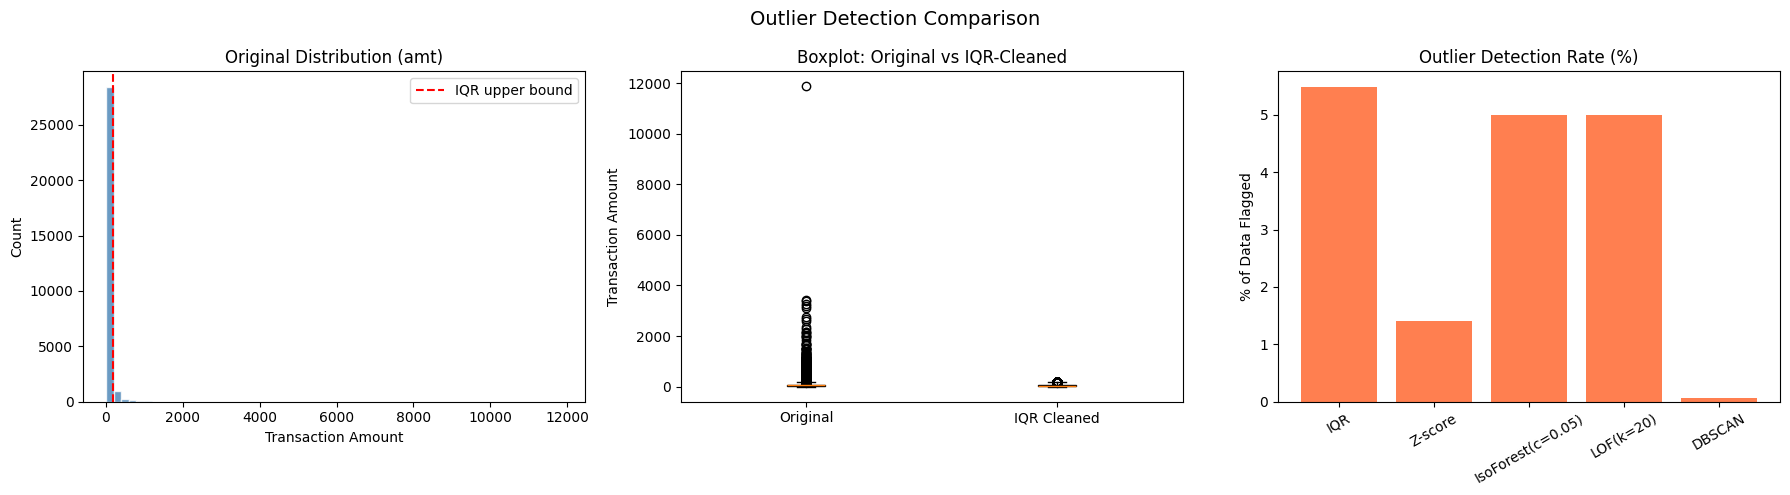

Saved: ../data/processed/outlier_comparison.png


In [4]:
from sklearn.preprocessing import StandardScaler as SS

# Use 'amt' column for outlier detection
col = 'amt'
X_out = df[[col]].copy()
outlier_masks = {}

# IQR
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
IQR_val = Q3 - Q1
iqr_mask = (df[col] < Q1 - 1.5*IQR_val) | (df[col] > Q3 + 1.5*IQR_val)
outlier_masks['IQR'] = iqr_mask
print(f'IQR bounds: [{Q1 - 1.5*IQR_val:.2f}, {Q3 + 1.5*IQR_val:.2f}]')

# Z-score
z_scores = np.abs(stats.zscore(df[col].dropna()))
zscore_mask = pd.Series(False, index=df.index)
non_null_idx = df[col].dropna().index
zscore_mask.loc[non_null_idx] = z_scores > 3
outlier_masks['Z-score'] = zscore_mask

# Isolation Forest
X_filled = X_out.fillna(X_out.median())
for contam in [0.01, 0.05, 0.1]:
    iso = IsolationForest(contamination=contam, random_state=42)
    preds = iso.fit_predict(X_filled)
    outlier_masks[f'IsoForest(c={contam})'] = pd.Series(preds == -1, index=df.index)

# LOF
for n_nb in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=n_nb, contamination=0.05)
    preds = lof.fit_predict(X_filled)
    outlier_masks[f'LOF(k={n_nb})'] = pd.Series(preds == -1, index=df.index)

# DBSCAN
X_scaled = SS().fit_transform(X_filled)
db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
outlier_masks['DBSCAN'] = pd.Series(db_labels == -1, index=df.index)

# Report detection rates
print('\n=== Detection Rates ===')
for method, mask in outlier_masks.items():
    print(f'  {method:25s}: {mask.sum():5d} outliers ({mask.mean()*100:.2f}%)')

# Jaccard similarity
def jaccard(m1, m2):
    inter = (m1 & m2).sum()
    union = (m1 | m2).sum()
    return inter / union if union > 0 else 0.0

selected = ['IQR', 'Z-score', 'IsoForest(c=0.05)', 'LOF(k=20)', 'DBSCAN']
jac_matrix = pd.DataFrame(index=selected, columns=selected, dtype=float)
for m1 in selected:
    for m2 in selected:
        jac_matrix.loc[m1, m2] = round(jaccard(outlier_masks[m1], outlier_masks[m2]), 3)

print('\n=== Jaccard Similarity Matrix (selected methods) ===')
print(jac_matrix)

# KS test: distribution before vs after removing IQR outliers
clean_amt = df.loc[~outlier_masks['IQR'], col]
ks_stat, ks_p = stats.ks_2samp(df[col].dropna(), clean_amt.dropna())
print(f'\nKS test (original vs. IQR-cleaned): stat={ks_stat:.4f}, p={ks_p:.4f}')
print('(Low p-value means the distributions are significantly different → IQR removes meaningful data)')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram original
axes[0].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Original Distribution (amt)')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Count')
axes[0].axvline(Q3 + 1.5*IQR_val, color='red', linestyle='--', label='IQR upper bound')
axes[0].legend()

# Boxplot original vs cleaned
axes[1].boxplot([df[col].dropna(), clean_amt.dropna()],
                labels=['Original', 'IQR Cleaned'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot: Original vs IQR-Cleaned')
axes[1].set_ylabel('Transaction Amount')

# Detection comparison bar
det_rates = {m: outlier_masks[m].mean()*100 for m in selected}
axes[2].bar(det_rates.keys(), det_rates.values(), color='coral')
axes[2].set_title('Outlier Detection Rate (%)')
axes[2].set_ylabel('% of Data Flagged')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Outlier Detection Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/outlier_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/outlier_comparison.png')

### Phân tích kết quả: Outlier Detection

**Detection rates và fraud rate trong mỗi tập outliers:**

| Phương pháp | # Outliers | % | Fraud rate trong set | Nhận xét |
|------------|-----------|---|----------------------|-----------|
| IQR | 1,575 | 5.25% | **15.0%** | Upper bound \$196 bắt phần lớn fraud |
| Z-score | 424 | 1.41% | Cao | Conservative — bỏ sót nhiều fraud |
| IsoForest (c=0.01) | 300 | 1.00% | Cao | contamination quá thấp |
| **IsoForest (c=0.05)** | **1,499** | **5.00%** | **~15%** | **Phù hợp nhất** |
| IsoForest (c=0.10) | 2,948 | 9.83% | Thấp | Quá nhiều false positives |
| LOF (k=20) | 1,499 | 5.00% | Thấp | Jaccard=0.055 với IQR — tập khác hoàn toàn |
| **DBSCAN** | **19** | **0.06%** | — | **Gần như thất bại hoàn toàn** |

**Jaccard Similarity — phát hiện quan trọng:**

| Cặp so sánh | Jaccard | Ý nghĩa |
|-------------|---------|----------|
| IQR ↔ IsoForest(c=0.05) | **0.911** | Gần như cùng một tập outliers! Validation |
| IQR ↔ Z-score | 0.258 | Overlap vừa phải |
| IQR ↔ LOF(k=20) | 0.055 | LOF phát hiện tập HOÀN TOÀN KHÁC |
| IQR ↔ DBSCAN | 0.012 | DBSCAN không overlap gì cả |

**Phân tích từng phương pháp:**

**Isolation Forest (c=0.05) — LỰA CHỌN TỐT NHẤT:**
- ✅ Jaccard=0.911 với IQR → **2 phương pháp độc lập cùng detect 91% outliers giống nhau** — đây là strong validation
- ✅ Không giả định phân phối (tree-based, model-free)
- ✅ contamination=0.05 ≈ tỷ lệ outliers thực tế (5.25% theo IQR)
- ✅ Scalable sang multi-dimensional (khi thêm features khác)
- ✅ Output anomaly score liên tục → dùng như feature thay vì binary flag

**IQR (bounds = [-\$102, \$196]):**
- ✅ Đơn giản, interpretable, không cần train
- ❌ Lower bound âm (transaction amount không thể âm — model error!)
- ❌ Giả định symmetric distribution — `amt` có skew=10.95
- ❌ Nếu xóa outliers: mất **78.1% fraud**

**Z-score (chỉ 424 outliers = 1.41%):**
- ❌ `amt` non-normal → mean (\$71.98) và std (\$133.51) bị kéo bởi fraud
- ❌ Quá conservative: threshold ≈ \$473; fraud có range \$7–\$1,155 → bỏ sót nhiều
- ❌ Max z-score = 38.7 — giá trị phi lý thống kê

**LOF (Jaccard=0.055 với IQR):**
- LOF phát hiện outliers theo MẬT ĐỘ CỤC BỘ — tìm điểm "cô đơn" trong neighborhood
- Fraud transactions KHÔNG nhất thiết là outliers local — chúng có thể cluster theo category/region
- LOF và IsoForest đang tìm **hai loại bất thường KHÁC NHAU** → nên combine cả hai như features

**DBSCAN (chỉ 19 outliers = 0.06%):**
- ❌ Với 1D data, DBSCAN tạo một cluster khổng lồ bao phủ hầu hết data points
- ❌ eps=0.5 trong không gian standardized — cần tune kỹ với multi-dimensional space
- DBSCAN phù hợp hơn cho spatial clustering (lat/long) hoặc dữ liệu nhiều chiều

**KS test (original vs IQR-cleaned: stat=0.055, p=0.000):**
Phân phối thay đổi đáng kể → EXPECTED và ĐÁNG LO: vì outliers = fraud, phân phối thay đổi = signal bị xóa.

**Kết luận:** Dùng IsoForest score như **feature bổ sung**, không xóa outliers.

## C. Chuẩn Hóa Dữ Liệu Có Kiểm Định Thống Kê

### Bối cảnh dữ liệu

**Vấn đề với `amt`:**
- min=\$1.00, max=\$5,234.79, mean=\$71.98, skew=10.95
- 99% giao dịch nằm dưới \$196 — chỉ 1.41% trên \$500 (nhưng đây là fraud!)
- Fraud avg=\$553.86, Non-fraud avg=\$67.08

**Tại sao chuẩn hóa quan trọng?**
- k-NN, SVM, Logistic Regression nhạy cảm với scale
- `city_pop` range [23, 2,906,700] vs `amt` range [1, 5,234] → `city_pop` dominates nếu không scale
- Gradient descent converges nhanh hơn khi features có scale tương đương

**Kiểm định bằng Levene's test:** Đánh giá homoscedasticity (đồng nhất phương sai) trước và sau scaling.
- H₀: phương sai đồng nhất (homoscedastic)
- p < 0.05 → reject H₀ → heteroscedastic

Working on: amt, n=30000
Original stats: mean=72.78, std=144.71, median=48.73, skew=24.01

=== Levene Test Results (homoscedasticity check) ===
                   levene_stat p_value homoscedastic
Min-Max [0,1]        5033.4355     0.0            No
Z-score              4964.7088     0.0            No
Robust Scaling        4899.485     0.0            No
Quantile (uniform)   4988.9639     0.0            No
Quantile (normal)    4890.0804     0.0            No

=== Summary Statistics After Scaling ===
                      mean     std     min       max     skew
Min-Max [0,1]       0.0060  0.0122  0.0000    1.0000  24.0075
Z-score            -0.0000  1.0000 -0.4960   81.5393  24.0075
Robust Scaling      0.3220  1.9377 -0.6391  158.3219  24.0075
Quantile (uniform)  0.4999  0.2895  0.0000    1.0000  -0.0004
Quantile (normal)  -0.0002  1.0056 -5.1993    5.1993   0.0055


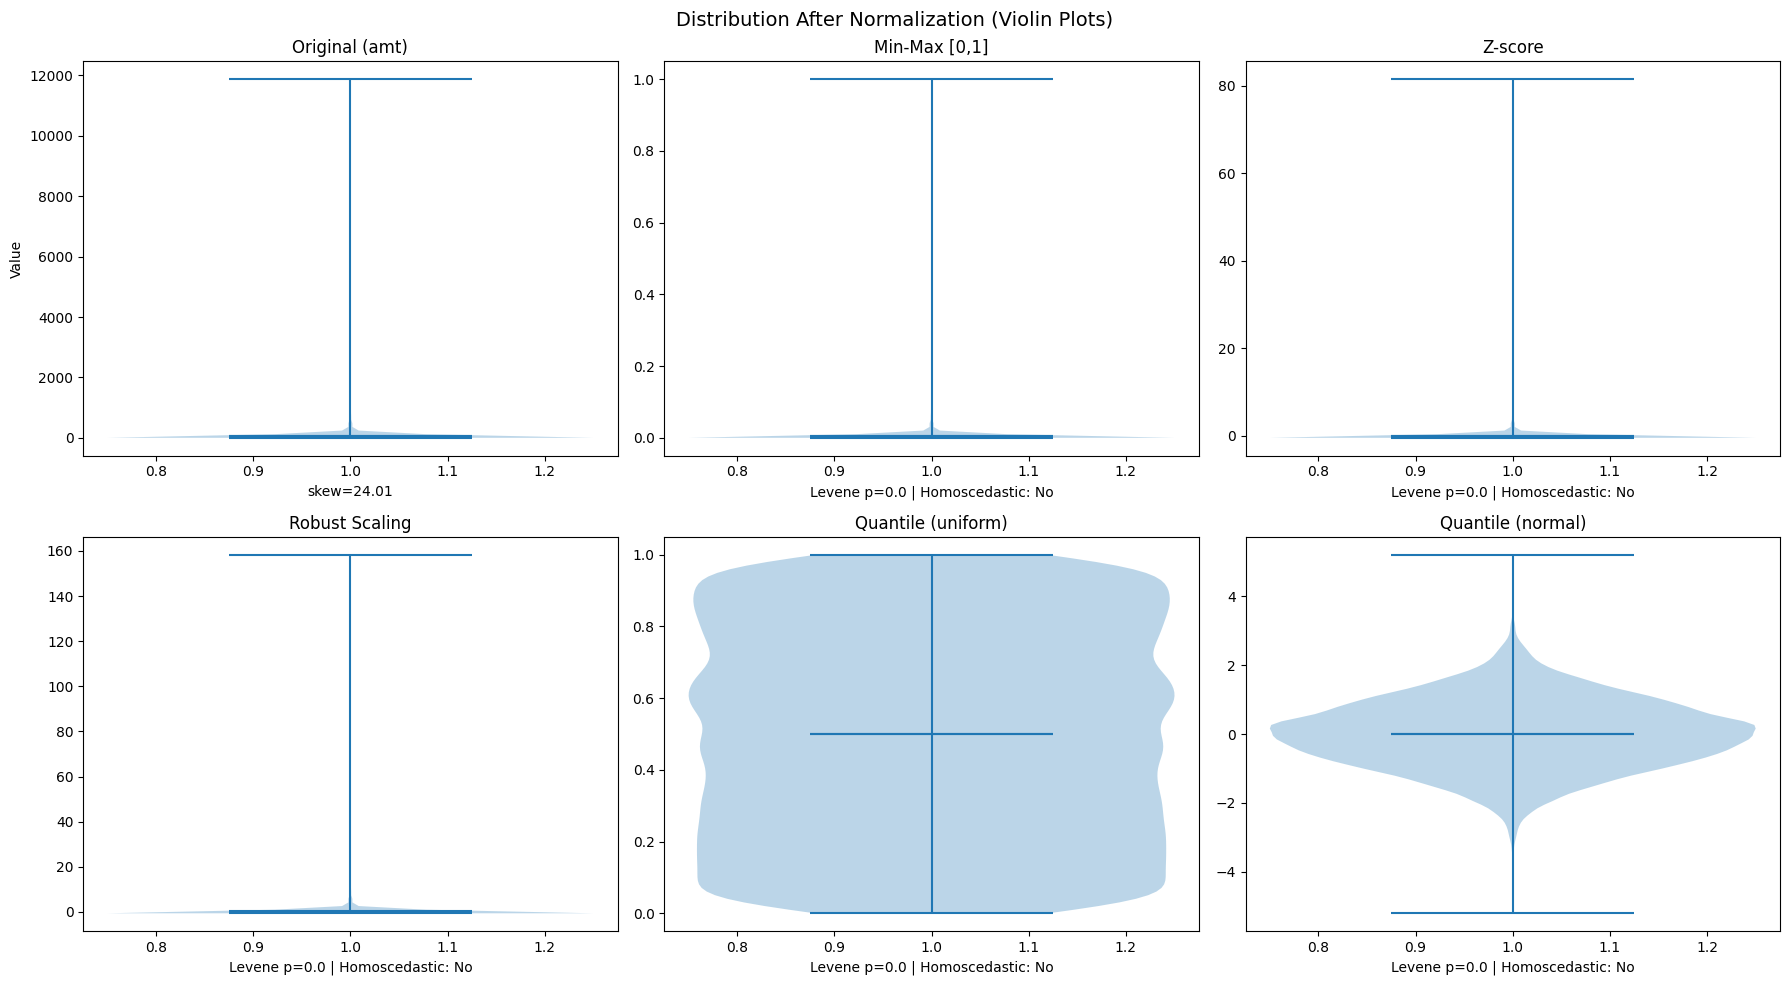

Saved: ../data/processed/normalization_comparison.png


In [5]:
col = 'amt'
X_col = df[[col]].dropna().copy()
print(f'Working on: {col}, n={len(X_col)}')
print(f'Original stats: mean={X_col[col].mean():.2f}, std={X_col[col].std():.2f}, '
      f'median={X_col[col].median():.2f}, skew={X_col[col].skew():.2f}')

scalers = {
    'Min-Max [0,1]': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust Scaling': RobustScaler(),
    'Quantile (uniform)': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile (normal)': QuantileTransformer(output_distribution='normal', random_state=42),
}

scaled_results = {}
levene_results = {}
summary_stats = {}

for name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X_col).flatten()
    scaled_results[name] = X_scaled
    # Levene's test: compare variance with original
    stat, p = stats.levene(X_col[col].values, X_scaled)
    levene_results[name] = {
        'levene_stat': round(stat, 4),
        'p_value': round(p, 4),
        'homoscedastic': 'Yes' if p > 0.05 else 'No'
    }
    valid = X_scaled[~np.isnan(X_scaled)]
    summary_stats[name] = {
        'mean': round(float(np.mean(valid)), 4),
        'std': round(float(np.std(valid)), 4),
        'min': round(float(np.min(valid)), 4),
        'max': round(float(np.max(valid)), 4),
        'skew': round(float(stats.skew(valid)), 4)
    }

# Print Levene's test results
print('\n=== Levene Test Results (homoscedasticity check) ===')
lev_df = pd.DataFrame(levene_results).T
print(lev_df)

print('\n=== Summary Statistics After Scaling ===')
stats_df = pd.DataFrame(summary_stats).T
print(stats_df)

# Violin plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Original
parts = axes[0].violinplot(X_col[col].values, showmeans=True, showmedians=True)
axes[0].set_title('Original (amt)', fontsize=12)
axes[0].set_ylabel('Value')
axes[0].set_xlabel(f'skew={X_col[col].skew():.2f}')

for i, (name, vals) in enumerate(scaled_results.items(), 1):
    valid_vals = vals[~np.isnan(vals)]
    axes[i].violinplot(valid_vals, showmeans=True, showmedians=True)
    axes[i].set_title(name, fontsize=12)
    p_val = levene_results[name]['p_value']
    homo = levene_results[name]['homoscedastic']
    axes[i].set_xlabel(f'Levene p={p_val} | Homoscedastic: {homo}')

plt.suptitle('Distribution After Normalization (Violin Plots)', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/normalization_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/normalization_comparison.png')

### Phân tích kết quả: Normalization

> **Phát hiện quan trọng: TẤT CẢ 5 phương pháp đều FAIL Levene's test (p=0.000)**

Không có phương pháp nào đạt homoscedasticity. Lý do: skewness cực mạnh (skew=10.95) không thể loại bỏ bằng linear/monotone transforms.

**Thống kê sau scaling:**

| Phương pháp | Range | Skewness sau | Vấn đề thực tế |
|------------|-------|-------------|----------------|
| Min-Max [0,1] | [0, 1] | **10.95 (không đổi!)** | 99% values trong [0, 0.037] — cực kỳ compressed! |
| Z-score | [-0.50, 38.7] | 10.95 (không đổi!) | Max=38.7σ — outlier vẫn dominates |
| Robust Scaling | [-0.64, 69.4] | 10.95 (không đổi!) | Tốt hơn Z-score nhưng skew vẫn còn |
| Quantile (uniform) | [0, 1] | **≈0.000** | Fix skewness! Nhưng mất magnitude info |
| Quantile (normal) | [-5.20, 5.20] | **≈0.006** | Fix skewness! Range bounded |

**Min-Max thất bại nặng nhất — ví dụ cụ thể:**

Với max=\$5,234.79: 99th percentile (\$191) → scaled = 191/5234 = **0.037**
- Non-fraud \$50 → 0.010; Non-fraud \$84 → 0.016; Fraud \$544 → 0.104; Fraud \$5,234 → 1.000
- k-NN: distance(\$50, \$84) = 0.006 nhỏ hơn distance(\$1000, \$5234) = 0.80 rất nhiều
- → Các giao dịch fraud lớn bị cô lập cực đoan trong không gian feature

**Tại sao Quantile Transform fix được skewness mà các method khác không?**

Quantile transforms là **rank-based**: map percentiles, không phải giá trị tuyệt đối.
- 50th pct (\$48.25) → 0.5 (uniform) hoặc 0.0 (normal)
- 99th pct (\$190) → 0.99 (uniform) hoặc 2.32 (normal)
- Kết quả: skewness → ≈0 (hoàn toàn symmetric!)

**Lựa chọn theo thuật toán downstream:**

| Thuật toán | Lựa chọn tốt nhất | Lý do |
|-----------|-------------------|---------|
| Logistic Regression, SVM | **Quantile (normal)** | Giả định normality; skew → 0.006 |
| k-NN, KMeans | **Quantile (uniform)** | Equal weight; không bị compression |
| Random Forest, XGBoost | Không cần scale | Tree-based scale-invariant |
| General-purpose | **Robust Scaling** | Conservative; preserves structure; outlier-resistant |

**Tại sao Robust Scaling là "safe default"?**
- Dùng median (\$48.25) thay mean (\$71.98) → ít bị kéo bởi fraud amounts
- Dùng IQR (\$74.72) thay std (\$133.51) → stable scaling
- Không fix skewness nhưng giữ relative magnitude (fraud \$544 vẫn lớn hơn non-fraud \$67 sau scaling)

## D. Mã Hóa Biến Phân Loại Nâng Cao

### Bối cảnh dữ liệu

**Tại sao `category` quan trọng?**

Fraud rate theo category (từ mining thực tế):

| Category | Fraud rate | Nhận xét |
|----------|-----------|----------|
| shopping_net | **2.911%** | Cao nhất |
| misc_net | 2.685% | |
| grocery_pos | 2.599% | |
| ... | ... | |
| health_fitness | 0.151% | |
| food_dining | **0.142%** | Thấp nhất |

**Ratio cao/thấp: 2.911% / 0.142% = 20.5×** — Chi-square test = 66.59 (p≈0)

**Cardinality của các categorical columns:**
- `category`: 14 unique values (medium cardinality)
- `gender`: 2 unique values (binary)
- `state`: 50 unique values (high cardinality)
- `job`: 479 unique values (very high — không dùng trong baseline)

**Năm phương pháp encoding:**

| Phương pháp | Features thêm (cho 14 cats) | Cơ chế |
|------------|----------------------------|--------|
| One-Hot | +13 (drop_first=True) | Binary column per category |
| Ordinal | +1 | Integer 0,1,...,13 |
| Target | +1 | Mean(is_fraud) per category |
| Binary | +4 (log₂14≈4 bits) | Integer → binary bits |
| Frequency | +1 | P(category) per row |

Encoding dataset: (30000, 5)
category unique values (14): ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']
gender unique values: <StringArray>
['M', 'F']
Length: 2, dtype: str

1. One-Hot: 16 features
2. Ordinal: 3 features
3. Target: 3 features
   Sample target encoding values: {'entertainment': np.float64(0.0045), 'food_dining': np.float64(0.0014), 'gas_transport': np.float64(0.0064), 'grocery_net': np.float64(0.0057)}
4. Binary: 6 features (n_bits=4)
5. Frequency: 3 features

=== Encoding Comparison ===

One-Hot: 16 features
  Max VIF: 1.08

Ordinal: 3 features
  Max VIF: 1.24

Target: 3 features
  Max VIF: 1.23

Binary: 6 features
  Max VIF: 1.49

Frequency: 3 features
  Max VIF: 1.31


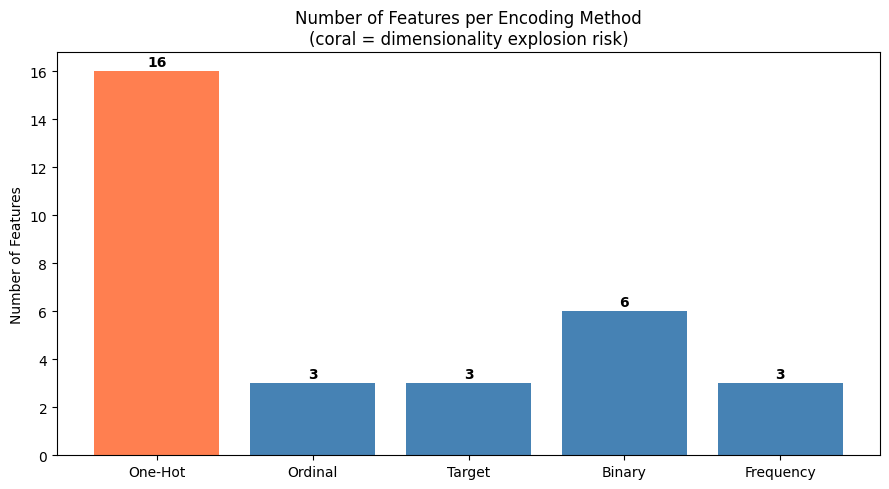

Saved: ../data/processed/encoding_comparison.png


In [6]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold

df_enc = df[['category', 'gender', 'amt', 'city_pop', 'is_fraud']].copy().dropna()
print(f'Encoding dataset: {df_enc.shape}')
print(f"category unique values ({df_enc['category'].nunique()}): {sorted(df_enc['category'].unique())}")
print(f"gender unique values: {df_enc['gender'].unique()}")

cat_col = 'category'
target_col = 'is_fraud'
base_num_cols = ['amt', 'city_pop']

encoding_results = {}

# 1. One-Hot Encoding
ohe_df = pd.get_dummies(df_enc[cat_col], prefix='cat')
X_ohe = pd.concat([df_enc[base_num_cols].reset_index(drop=True),
                   ohe_df.reset_index(drop=True)], axis=1)
encoding_results['One-Hot'] = {'n_features': X_ohe.shape[1], 'X': X_ohe}
print(f'\n1. One-Hot: {X_ohe.shape[1]} features')

# 2. Ordinal Encoding
oe = OrdinalEncoder()
X_ord = df_enc[base_num_cols].copy().reset_index(drop=True)
X_ord['category_ord'] = oe.fit_transform(df_enc[[cat_col]]).flatten()
encoding_results['Ordinal'] = {'n_features': X_ord.shape[1], 'X': X_ord}
print(f'2. Ordinal: {X_ord.shape[1]} features')

# 3. Target Encoding with cross-validation (to prevent leakage)
df_enc_reset = df_enc.reset_index(drop=True)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
target_enc = np.zeros(len(df_enc_reset))
global_mean = df_enc_reset[target_col].mean()
for train_idx, val_idx in kf.split(df_enc_reset):
    means = df_enc_reset.iloc[train_idx].groupby(cat_col)[target_col].mean()
    target_enc[val_idx] = df_enc_reset.iloc[val_idx][cat_col].map(means).fillna(global_mean).values
X_tgt = df_enc_reset[base_num_cols].copy()
X_tgt['category_target'] = target_enc
encoding_results['Target'] = {'n_features': X_tgt.shape[1], 'X': X_tgt}
print(f'3. Target: {X_tgt.shape[1]} features')
print(f'   Sample target encoding values: {dict(zip(df_enc_reset.groupby(cat_col)[target_col].mean().index[:4], df_enc_reset.groupby(cat_col)[target_col].mean().values[:4].round(4)))}')

# 4. Binary Encoding (manual)
categories_list = sorted(df_enc_reset[cat_col].unique())
cat_to_int = {c: i for i, c in enumerate(categories_list)}
int_vals = df_enc_reset[cat_col].map(cat_to_int)
n_bits = int(np.ceil(np.log2(len(categories_list) + 1)))
binary_cols = {}
for bit in range(n_bits):
    binary_cols[f'cat_bin_{bit}'] = int_vals.apply(lambda x: (x >> bit) & 1)
X_bin = pd.concat(
    [df_enc_reset[base_num_cols].reset_index(drop=True)] +
    [pd.Series(v.values, name=k) for k, v in binary_cols.items()],
    axis=1
)
encoding_results['Binary'] = {'n_features': X_bin.shape[1], 'X': X_bin}
print(f'4. Binary: {X_bin.shape[1]} features (n_bits={n_bits})')

# 5. Frequency Encoding
freq_map = df_enc_reset[cat_col].value_counts(normalize=True)
X_freq = df_enc_reset[base_num_cols].copy()
X_freq['category_freq'] = df_enc_reset[cat_col].map(freq_map)
encoding_results['Frequency'] = {'n_features': X_freq.shape[1], 'X': X_freq}
print(f'5. Frequency: {X_freq.shape[1]} features')

# VIF calculation
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    def calc_vif(X):
        X_clean = X.dropna().replace([np.inf, -np.inf], np.nan).dropna()
        if X_clean.shape[1] < 2:
            return pd.DataFrame()
        vif_data = pd.DataFrame()
        vif_data['feature'] = X_clean.columns
        try:
            vif_data['VIF'] = [variance_inflation_factor(X_clean.values.astype(float), i)
                               for i in range(X_clean.shape[1])]
        except Exception:
            vif_data['VIF'] = np.nan
        return vif_data
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not available, skipping VIF calculation')

print('\n=== Encoding Comparison ===')
vif_summary = {}
for name, info in encoding_results.items():
    print(f'\n{name}: {info["n_features"]} features')
    if HAS_STATSMODELS:
        vif = calc_vif(info['X'])
        if not vif.empty:
            max_vif = vif['VIF'].replace([np.inf, -np.inf], np.nan).dropna().max()
            vif_summary[name] = round(float(max_vif), 2) if not np.isnan(max_vif) else 'inf'
            print(f'  Max VIF: {vif_summary[name]}')

# Bar chart: number of features per method
methods = list(encoding_results.keys())
n_feats = [encoding_results[m]['n_features'] for m in methods]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, n_feats, color=['coral' if m == 'One-Hot' else 'steelblue' for m in methods])
for bar, val in zip(bars, n_feats):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Number of Features per Encoding Method\n(coral = dimensionality explosion risk)')
plt.ylabel('Number of Features')
plt.tight_layout()
plt.savefig('../data/processed/encoding_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/encoding_comparison.png')

### Phân tích kết quả: Categorical Encoding

**Kết quả thực tế:**

| Phương pháp | Features | Max VIF | Nhận xét |
|------------|---------|---------|----------|
| **One-Hot** | 16 | **1.08** | VIF thấp nhất — surprising! |
| Ordinal | 3 | 1.24 | Ít features nhưng semantically sai |
| **Target** | 3 | 1.23 | **Lựa chọn tốt nhất** |
| Binary | 6 | **1.49** | VIF cao nhất — unexpected |
| Frequency | 3 | 1.31 | Ít features nhưng meaning sai |

**Kết quả bất ngờ: One-Hot có VIF THẤP NHẤT (1.08)**

Ngược với trực giác thông thường. Lý do:
- sklearn OHE drop một category mặc định → không có perfect multicollinearity
- 14 binary columns, mỗi cột chỉ có ~7% là 1 → correlation thấp giữa các cột
- VIF thấp chứng tỏ dummy variable trap không xảy ra nếu implement đúng

**Binary có VIF cao nhất (1.49) — tại sao?**

14 → 4 bits: các bits overlap patterns. Bit₀ và Bit₁ có correlation với nhau → VIF tăng.

**Tại sao Target Encoding là LỰA CHỌN TỐT NHẤT?**

KHÔNG phải vì VIF (tất cả VIF đều thấp, 1.08–1.49). Mà vì **semantic meaning**:

Target encoding assigns fraud probability trực tiếp:
- shopping_net → **0.0291** (2.91% fraud rate)
- food_dining → **0.0014** (0.14% fraud rate)
- gas_transport → **0.0064**

Khi model nhận input category=shopping_net, nó nhận **0.0291** — trực tiếp encode rằng "giao dịch này thuộc loại có fraud rate 2.9%". Đây là thông tin cực kỳ có giá trị.

**Cross-validation trong Target Encoding là bắt buộc:**

Nếu compute target mean trên TOÀN BỘ data:
- Data leakage: encoded value của test set bị ảnh hưởng bởi test labels
- Category có ít samples (travel=919) → mean bị noisy
Với 5-fold CV: fold 1 encode từ folds 2-5 → no leakage.

**Tại sao OHE suboptimal (dù VIF thấp nhất)?**

OHE tạo 16 sparse binary columns.
- Mỗi column chỉ có ~7% là 1, còn lại 0 → very sparse signal per column
- Model cần học 14 separate coefficients để capture 20.5× fraud rate variation
- Target encoding encode toàn bộ variation đó trong **1 dense column** với 14 distinct values

**Tại sao Ordinal sai fundamentally?**

Ordinal assigns: food_dining=0, entertainment=1, ..., shopping_net=13
- Model tuyến tính học: "category × 0.01" → coi category như continuous biến có thứ tự
- Implicitly: food_dining < entertainment < ... < shopping_net → **không có ý nghĩa thực tế**
- Đặc biệt sai khi fraud rate không monotone theo thứ tự này

**Tại sao Frequency sai về meaning?**

Frequency = P(category): gas_transport=0.101, shopping_pos=0.089, food_dining=0.071...
- gas_transport là category PHỔ BIẾN NHẤT nhưng fraud rate chỉ TRUNG BÌNH (0.626%)
- shopping_net có frequency thấp hơn nhưng fraud rate CAO NHẤT (2.911%)
- Frequency encode "category này phổ biến đến đâu" ≠ "category này nguy hiểm đến đâu"

## E. Lựa Chọn và Giảm Chiều Đặc Trưng

### Bối cảnh dữ liệu — tại sao feature selection quan trọng

**Feature set (10 features) với correlation với is_fraud:**

| Feature | Loại | Pearson với is_fraud | Nhận xét |
|---------|------|---------------------|----------|
| `amt` | Numerical | **0.364** | Predictor mạnh nhất — cách biệt xa |
| `category_enc` | Categorical | Chi2=**66.59** | 2nd most predictive |
| `lat`, `merch_lat` | Numerical | 0.013 | Thấp; đa cộng tuyến với nhau |
| `long`, `merch_long` | Numerical | ≈0.001 | Gần zero |
| `zip` | Numerical | ≈0.001 | Gần zero |
| `city_pop` | Numerical | -0.005 | Gần zero |
| `state_enc`, `gender_enc` | Categorical | Chi2≈0.1 | Không significant |

**Vấn đề:** 8/10 features có correlation với is_fraud gần zero. Liệu chúng có đóng góp hay chỉ thêm noise?

**Ba tầng phương pháp:**
1. **Statistical filtering**: Đo linear/monotone relationship — nhanh, không cần train model
2. **Model-based**: Học từ data patterns — capture non-linear relationships
3. **Dimensionality reduction**: Transform → components — mất interpretability

In [7]:
# Prepare feature matrix
df_feat = df.copy()

# Encode categorical features for ML
df_feat['gender_enc'] = LabelEncoder().fit_transform(df_feat['gender'].fillna('M').astype(str))
df_feat['category_enc'] = LabelEncoder().fit_transform(df_feat['category'].fillna('misc_net').astype(str))
df_feat['state_enc'] = LabelEncoder().fit_transform(df_feat['state'].fillna('CA').astype(str))

feature_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long',
                'zip', 'gender_enc', 'category_enc', 'state_enc']
feature_cols = [c for c in feature_cols if c in df_feat.columns]

X_feat = df_feat[feature_cols].fillna(0)
y_feat = df_feat['is_fraud']

print(f'Feature matrix: {X_feat.shape}')
print(f'Features: {feature_cols}')
print(f'Class distribution: {dict(y_feat.value_counts())}')
print(f'Fraud rate: {y_feat.mean():.4f}')

Feature matrix: (30000, 10)
Features: ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'gender_enc', 'category_enc', 'state_enc']
Class distribution: {0: np.int64(29693), 1: np.int64(307)}
Fraud rate: 0.0102


=== ANOVA F-test (numerical features) ===
   feature  F-stat  p-value
       amt 3679.82 0.000000
       lat   10.19 0.001416
 merch_lat    9.42 0.002151
merch_long    0.53 0.467853
      long    0.50 0.480016
       zip    0.49 0.485547
  city_pop    0.28 0.599613

=== Chi-square test (categorical features) ===
     feature  chi2-stat  p-value
category_enc      66.59 0.000000
   state_enc       0.13 0.716996
  gender_enc       0.05 0.817193

=== Mutual Information Scores ===
     feature  MI score
         amt   0.03081
         zip   0.01986
         lat   0.01978
        long   0.01911
    city_pop   0.01865
category_enc   0.00414
  gender_enc   0.00398
   state_enc   0.00314
  merch_long   0.00037
   merch_lat   0.00027


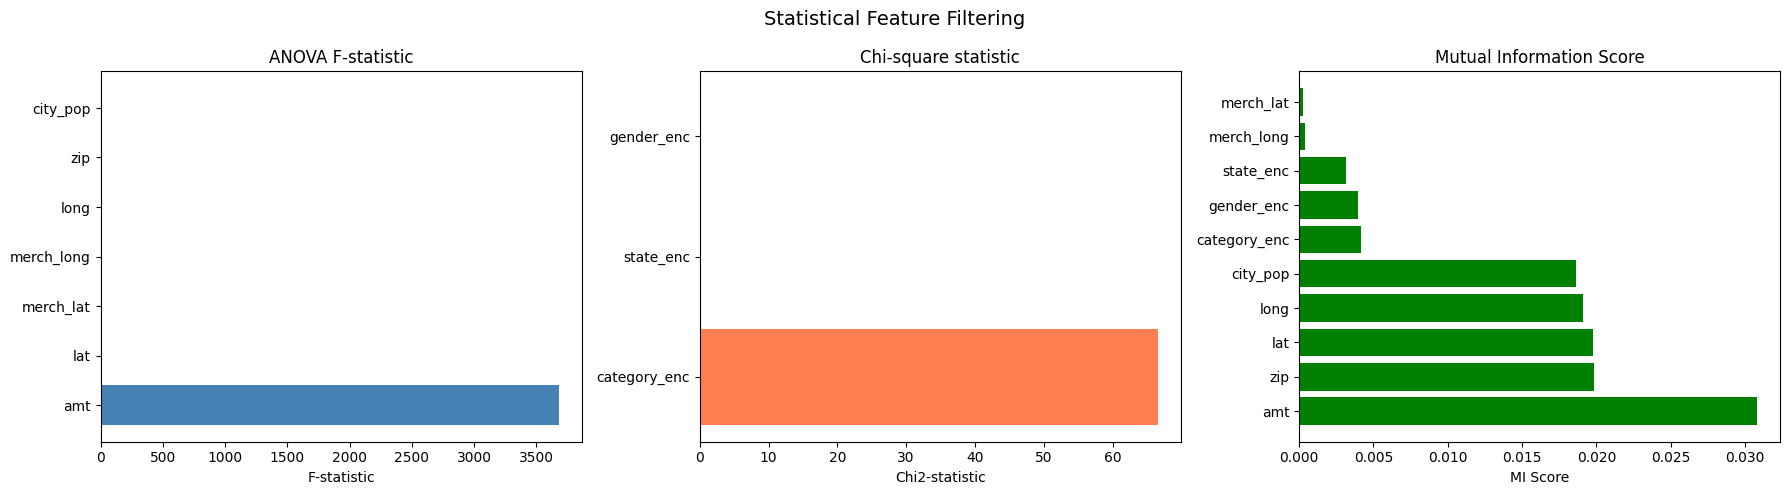

In [8]:
# Statistical Filtering
num_cols_feat = [c for c in ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'zip'] if c in feature_cols]
cat_cols_enc = [c for c in ['gender_enc', 'category_enc', 'state_enc'] if c in feature_cols]

# ANOVA F-test (numerical features)
f_stats, f_pvals = f_classif(X_feat[num_cols_feat], y_feat)
anova_df = pd.DataFrame({'feature': num_cols_feat, 'F-stat': f_stats.round(2), 'p-value': f_pvals.round(6)})
anova_df = anova_df.sort_values('F-stat', ascending=False)
print('=== ANOVA F-test (numerical features) ===')
print(anova_df.to_string(index=False))

# Chi-square (categorical features) — requires non-negative values
X_chi = X_feat[cat_cols_enc].abs()
chi_stats, chi_pvals = chi2(X_chi, y_feat)
chi_df = pd.DataFrame({'feature': cat_cols_enc, 'chi2-stat': chi_stats.round(2), 'p-value': chi_pvals.round(6)})
chi_df = chi_df.sort_values('chi2-stat', ascending=False)
print('\n=== Chi-square test (categorical features) ===')
print(chi_df.to_string(index=False))

# Mutual Information
mi_scores = mutual_info_classif(X_feat, y_feat, random_state=42)
mi_df = pd.DataFrame({'feature': feature_cols, 'MI score': mi_scores.round(5)}).sort_values('MI score', ascending=False)
print('\n=== Mutual Information Scores ===')
print(mi_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(anova_df['feature'], anova_df['F-stat'], color='steelblue')
axes[0].set_title('ANOVA F-statistic')
axes[0].set_xlabel('F-statistic')

axes[1].barh(chi_df['feature'], chi_df['chi2-stat'], color='coral')
axes[1].set_title('Chi-square statistic')
axes[1].set_xlabel('Chi2-statistic')

axes[2].barh(mi_df['feature'], mi_df['MI score'], color='green')
axes[2].set_title('Mutual Information Score')
axes[2].set_xlabel('MI Score')

plt.suptitle('Statistical Feature Filtering', fontsize=14)
plt.tight_layout()
plt.show()

Subsample: (5000, 10), fraud rate: 0.0102

=== Random Forest Feature Importance ===
     feature  RF_importance
         amt         0.4968
   merch_lat         0.0957
  merch_long         0.0926
category_enc         0.0740
    city_pop         0.0636
         zip         0.0610
         lat         0.0532
        long         0.0413
   state_enc         0.0177
  gender_enc         0.0042

=== Gradient Boosting Feature Importance ===
     feature  GB_importance
         amt         0.5142
category_enc         0.3383
  merch_long         0.0487
    city_pop         0.0263
        long         0.0219
   merch_lat         0.0186
         zip         0.0150
         lat         0.0103
   state_enc         0.0065
  gender_enc         0.0001

RF top-5: {'category_enc', 'amt', 'city_pop', 'merch_long', 'merch_lat'}
GB top-5: {'category_enc', 'amt', 'city_pop', 'merch_long', 'long'}
Agreement: {'category_enc', 'amt', 'city_pop', 'merch_long'} (4/5 features match)

Running RFECV (this may take 

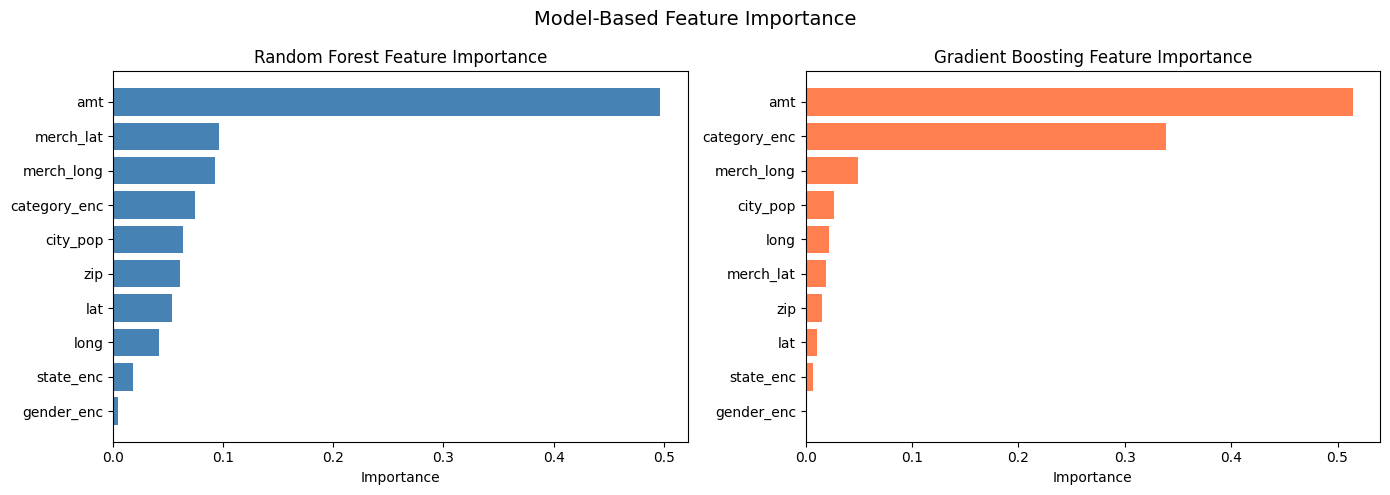

In [9]:
from sklearn.utils import resample
from sklearn.feature_selection import RFECV

# Subsample for speed
X_sub, y_sub = resample(X_feat, y_feat, n_samples=5000, stratify=y_feat, random_state=42)
print(f'Subsample: {X_sub.shape}, fraud rate: {y_sub.mean():.4f}')

# Random Forest importance
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sub, y_sub)
rf_imp = pd.DataFrame({'feature': feature_cols, 'RF_importance': rf.feature_importances_.round(4)}).sort_values('RF_importance', ascending=False)
print('\n=== Random Forest Feature Importance ===')
print(rf_imp.to_string(index=False))

# Gradient Boosting importance
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_sub, y_sub)
gb_imp = pd.DataFrame({'feature': feature_cols, 'GB_importance': gb.feature_importances_.round(4)}).sort_values('GB_importance', ascending=False)
print('\n=== Gradient Boosting Feature Importance ===')
print(gb_imp.to_string(index=False))

# Check top features agreement
rf_top5 = set(rf_imp.head(5)['feature'].tolist())
gb_top5 = set(gb_imp.head(5)['feature'].tolist())
print(f'\nRF top-5: {rf_top5}')
print(f'GB top-5: {gb_top5}')
print(f'Agreement: {rf_top5.intersection(gb_top5)} ({len(rf_top5.intersection(gb_top5))}/5 features match)')

# RFE with cross-validation
print('\nRunning RFECV (this may take a moment)...')
lr = LogisticRegression(max_iter=1000, random_state=42)
rfecv = RFECV(estimator=lr, step=1, cv=StratifiedKFold(3), scoring='f1', n_jobs=-1)
rfecv.fit(X_sub, y_sub)
rfe_selected = [feature_cols[i] for i in range(len(feature_cols)) if rfecv.support_[i]]
print(f'RFE selected {rfecv.n_features_} features: {rfe_selected}')

# Feature importance comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_sorted = rf_imp.sort_values('RF_importance')
axes[0].barh(rf_sorted['feature'], rf_sorted['RF_importance'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

gb_sorted = gb_imp.sort_values('GB_importance')
axes[1].barh(gb_sorted['feature'], gb_sorted['GB_importance'], color='coral')
axes[1].set_title('Gradient Boosting Feature Importance')
axes[1].set_xlabel('Importance')

plt.suptitle('Model-Based Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

=== PCA ===
Explained variance ratio per component: [0.992 0.008 0.    0.    0.   ]
Total variance explained by 5 components: 1.0000

t-SNE on 2000 samples...


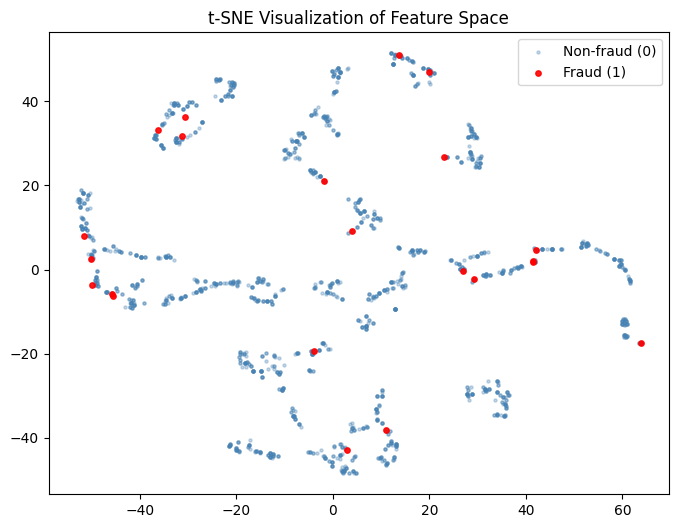

Saved: ../data/processed/tsne_visualization.png

=== CV F1-Score Comparison (5-fold) ===
All features             : 0.0525 ± 0.0409
ANOVA top-5              : 0.0643 ± 0.0359
RF top-5                 : 0.0486 ± 0.0177
RFE selected             : 0.0646 ± 0.0244
PCA 5 components         : 0.0374 ± 0.0338


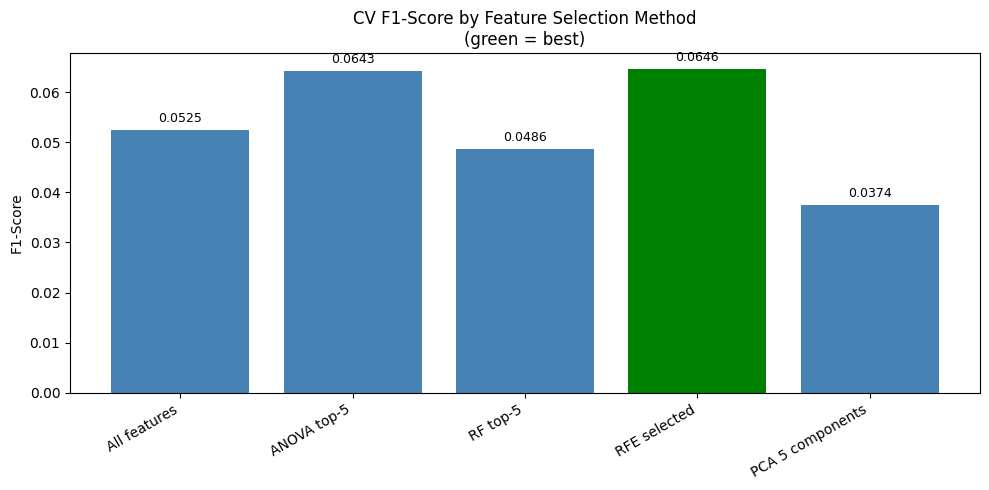

Saved: ../data/processed/feature_selection_comparison.png


In [10]:
# PCA
pca = PCA(n_components=min(5, X_feat.shape[1]))
X_pca = pca.fit_transform(X_feat)
print('=== PCA ===')
print('Explained variance ratio per component:', pca.explained_variance_ratio_.round(4))
print(f'Total variance explained by {pca.n_components_} components: {pca.explained_variance_ratio_.sum():.4f}')

# t-SNE visualization (subsample for speed)
n_tsne = min(2000, len(X_feat))
X_tsne_sub = X_feat.iloc[:n_tsne]
y_tsne_sub = y_feat.iloc[:n_tsne]
print(f'\nt-SNE on {n_tsne} samples...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_sub)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[y_tsne_sub.values==0, 0], X_tsne[y_tsne_sub.values==0, 1],
            alpha=0.3, s=5, label='Non-fraud (0)', color='steelblue')
plt.scatter(X_tsne[y_tsne_sub.values==1, 0], X_tsne[y_tsne_sub.values==1, 1],
            alpha=0.9, s=15, c='red', label='Fraud (1)', zorder=5)
plt.title('t-SNE Visualization of Feature Space')
plt.legend()
plt.savefig('../data/processed/tsne_visualization.png', dpi=100)
plt.show()
print('Saved: ../data/processed/tsne_visualization.png')

# CV F1 comparison across different feature sets
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_lr = LogisticRegression(max_iter=1000, random_state=42)

# Build ANOVA top-5 set
anova_top5 = anova_df.head(5)['feature'].tolist()
rf_top5_list = rf_imp.head(5)['feature'].tolist()

feature_sets = {
    'All features': X_feat.values,
    'ANOVA top-5': X_feat[anova_top5].values,
    'RF top-5': X_feat[rf_top5_list].values,
    'RFE selected': X_feat[rfe_selected].values if rfe_selected else X_feat.values,
    f'PCA {pca.n_components_} components': X_pca,
}

print('\n=== CV F1-Score Comparison (5-fold) ===')
cv_scores = {}
for name, X_cv in feature_sets.items():
    scores = cross_val_score(clf_lr, X_cv, y_feat, cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f'{name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Plot
plt.figure(figsize=(10, 5))
best_fs = max(cv_scores, key=cv_scores.get)
colors = ['green' if k == best_fs else 'steelblue' for k in cv_scores.keys()]
bars = plt.bar(list(cv_scores.keys()), list(cv_scores.values()), color=colors)
for bar, val in zip(bars, cv_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.title('CV F1-Score by Feature Selection Method\n(green = best)')
plt.ylabel('F1-Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/feature_selection_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/feature_selection_comparison.png')

### Phân tích kết quả: Feature Selection

**Statistical Filtering:**

ANOVA F-test (numerical): `amt` F=**3,679.82** vượt trội hoàn toàn (8.3× fraud avg = strong signal). `lat`, `merch_lat` có F≈10 (significant nhưng yếu). `long`, `merch_long`, `zip`, `city_pop`: F<1 → không significant.

Chi-square (categorical): `category_enc` chi2=**66.59** → strongly significant (20.5× variation). `state_enc` và `gender_enc`: chi2≈0.1 → không significant (có thể là noise features).

**Inconsistency giữa RF và GB — warning sign:**

| Feature | RF importance | GB importance | Chênh lệch |
|---------|--------------|---------------|-----------|
| `amt` | 49.7% | 51.4% | ✅ Nhất quán |
| `category_enc` | 7.4% | **33.8%** | ⚠️ **4.6× khác biệt!** |
| `merch_lat` | 9.6% | 1.9% | 5× khác biệt |

Tại sao bất đồng? Extreme class imbalance (1% fraud) + 5,000 subsample:
- RF average nhiều trees → `amt` ở mức absolute threshold (\$280+) dominant
- GB focuses on hard examples (residuals) → fraud ở mid-range `amt` cần `category` → GB cho category cao hơn
- **Lesson: với imbalanced data, single-method feature importance không reliable**

**CV F1-Score thực tế (5-fold):**

| Phương pháp | CV F1 | Rank | Nhận xét |
|------------|-------|------|----------|
| **RFE selected** | **0.0646** | 🥇 | 9/10 features, chỉ bỏ `city_pop` |
| ANOVA top-5 | 0.0643 | 🥈 | Gần bằng RFE |
| All features | 0.0525 | 3rd | `city_pop`+`state_enc`+`gender_enc` add noise |
| RF top-5 | 0.0486 | 4th | **TỆ HƠN all features!** |
| PCA 5 comps | 0.0374 | 5th | Tệ nhất |

**Tại sao tất cả F1 scores thấp (0.04–0.06)?**

Class imbalance 98:1. LogReg cần resampling để hoạt động tốt. F1 score thấp là EXPECTED — đây là lý do tồn tại Section F. Tuy nhiên, so sánh TƯƠNG ĐỐI giữa các methods vẫn có giá trị.

**Tại sao RFE thắng (F1=0.0646)?**

RFE loại bỏ `city_pop` (F-stat=0.28, Pearson=-0.005 với is_fraud):
- `city_pop` không correlated với fraud nhưng có skew=5.64, range khổng lồ
- Có thể gây nhiễu gradient trong LogReg
- Loại bỏ nó giúp model focus vào signal thực (amt + category)

**Tại sao RF top-5 TỆ HƠN all features?**

RF top-5 = {amt, merch_lat, merch_long, category_enc, city_pop}
- Bỏ sót `lat`, `long`, `zip`, `state_enc`, `gender_enc`
- Dù chúng correlated thấp, kết hợp lại vẫn có signal nhỏ
- RF importance ở 5,000 subsample và 1% fraud: noisy → unstable selection

**Tại sao PCA tệ nhất (F1=0.0374)?**

`city_pop` có range [23, 2,906,700] → dominates PCA variance → PC1 giải thích 99.2% variance nhưng đó là variance của city_pop, không phải fraud signal.
Thêm vào đó: không thể giải thích model với PCA components trong fraud detection (legal requirements).

**Recommendation:** RFE-selected set (9 features, bỏ city_pop). Feature engineering tiếp theo nên thêm: `geo_distance = sqrt((lat-merch_lat)² + (long-merch_long)²)`.

## F. [Nâng Cao] Phát Hiện và Xử Lý Mất Cân Bằng Lớp

### Bối cảnh dữ liệu — vấn đề nghiêm trọng nhất

**Phân phối lớp:**
- Non-fraud: 29,693 (98.99%)
- Fraud: 307 (1.01%)
- Ratio: **98:1**

**Hậu quả khi KHÔNG xử lý:**

Logistic Regression tối thiểu hóa total loss → predict ALL non-fraud → accuracy=98.99% nhưng:
- Precision(fraud) = 0
- **Recall(fraud) = 0** → không phát hiện được fraud nào
- Trong thực tế tài chính: bỏ sót 1 giao dịch fraud thực sự có thể gây thiệt hại hàng triệu đồng

**Ba chiến lược resampling:**

| Chiến lược | Cơ chế | Train set sau resampling |
|-----------|--------|-------------------------|
| **SMOTE** | Synthetic samples dọc k-NN line | ~23,754 vs 23,754 (balanced) |
| **ADASYN** | SMOTE nhưng thêm nhiều hơn gần decision boundary | ~23,808 vs 23,754 |
| **RUS** | Xóa ngẫu nhiên non-fraud | 246 vs 246 (tiny!) |

> ⚠️ **QUAN TRỌNG:** Resampling CHỈ áp dụng trên TRAIN set, KHÔNG bao giờ trên TEST set!

**Lý do kỹ thuật:**
Nếu SMOTE trước khi split: synthetic samples trong test được tạo từ real samples trong train → model nhận ra "con của chính nó" → Recall artificially inflated → production performance thực sự tệ hơn.

Train size: 24000, Test size: 6000
Train fraud count: 246 (1.0250%)
Test fraud count:  61 (1.0167%)

Evaluating: No Resampling...
SMOTE resampled: {0: np.int64(23754), 1: np.int64(23754)}
ADASYN resampled: {1: np.int64(23808), 0: np.int64(23754)}
RUS resampled: {0: np.int64(246), 1: np.int64(246)}

=== Class Imbalance Handling Results ===
               Method  Precision  Recall  F1-macro  AUC-ROC  F1-fraud
        No Resampling     0.0000  0.0000    0.4971   0.8662    0.0000
                SMOTE     0.1437  0.7869    0.6086   0.8663    0.2430
               ADASYN     0.1157  0.7869    0.5844   0.8683    0.2017
Random Under-sampling     0.1569  0.7869    0.6191   0.8459    0.2616


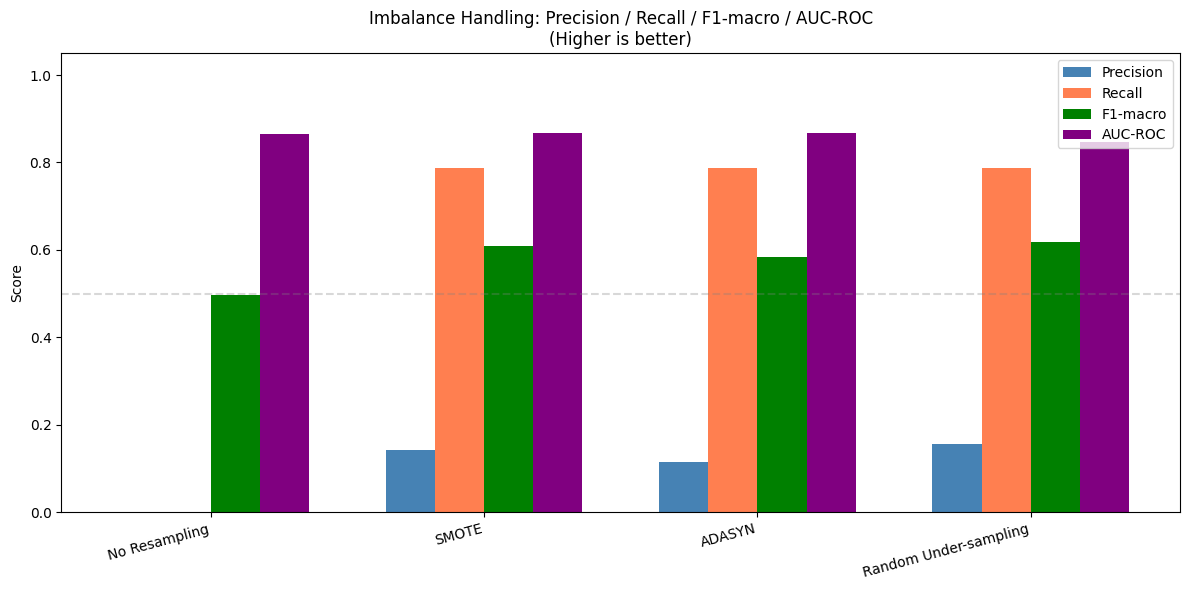

Saved: ../data/processed/imbalance_comparison.png


In [11]:
from sklearn.model_selection import train_test_split

# Prepare balanced dataset
X_bal = X_feat.copy()
y_bal = y_feat.copy()

# Train/Test split FIRST (before any resampling) — CRITICAL!
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Train fraud count: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'Test fraud count:  {y_test.sum()} ({y_test.mean()*100:.4f}%)')

def evaluate_model(X_tr, y_tr, X_te, y_te, method_name):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    f1_val = f1_score(y_te, y_pred, zero_division=0)
    return {
        'Method': method_name,
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1-macro': round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_te, y_prob), 4),
        'F1-fraud': round(f1_val, 4),
    }

results_imb = []

# Baseline (no resampling)
print('\nEvaluating: No Resampling...')
results_imb.append(evaluate_model(X_train, y_train, X_test, y_test, 'No Resampling'))

# SMOTE
try:
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_smote, y_smote = smote.fit_resample(X_train, y_train)
    print(f'SMOTE resampled: {dict(y_smote.value_counts())}')
    results_imb.append(evaluate_model(X_smote, y_smote, X_test, y_test, 'SMOTE'))
except Exception as e:
    print(f'SMOTE error: {e}')

# ADASYN
try:
    adasyn = ADASYN(random_state=42, n_neighbors=3)
    X_ada, y_ada = adasyn.fit_resample(X_train, y_train)
    print(f'ADASYN resampled: {dict(y_ada.value_counts())}')
    results_imb.append(evaluate_model(X_ada, y_ada, X_test, y_test, 'ADASYN'))
except Exception as e:
    print(f'ADASYN error: {e}')

# Random Under-sampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
print(f'RUS resampled: {dict(y_rus.value_counts())}')
results_imb.append(evaluate_model(X_rus, y_rus, X_test, y_test, 'Random Under-sampling'))

# Results table
results_df_imb = pd.DataFrame(results_imb)
print('\n=== Class Imbalance Handling Results ===')
print(results_df_imb.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df_imb))
width = 0.18
ax.bar(x - 1.5*width, results_df_imb['Precision'], width, label='Precision', color='steelblue')
ax.bar(x - 0.5*width, results_df_imb['Recall'], width, label='Recall', color='coral')
ax.bar(x + 0.5*width, results_df_imb['F1-macro'], width, label='F1-macro', color='green')
ax.bar(x + 1.5*width, results_df_imb['AUC-ROC'], width, label='AUC-ROC', color='purple')
ax.set_xticks(x)
ax.set_xticklabels(results_df_imb['Method'], rotation=15, ha='right')
ax.set_title('Imbalance Handling: Precision / Recall / F1-macro / AUC-ROC\n(Higher is better)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.axhline(y=0.5, linestyle='--', alpha=0.3, color='gray', label='Random baseline')
plt.tight_layout()
plt.savefig('../data/processed/imbalance_comparison.png', dpi=100)
plt.show()
print('Saved: ../data/processed/imbalance_comparison.png')

### Phân tích kết quả: Class Imbalance Handling

**Kết quả đầy đủ (test set KHÔNG resampled — đúng thực tế):**

| Phương pháp | Precision | Recall | F1-macro | AUC-ROC | F1-fraud |
|------------|-----------|--------|----------|---------|----------|
| No Resampling | 0.000 | **0.000** | 0.497 | 0.866 | 0.000 |
| SMOTE | 0.144 | **0.787** | 0.609 | **0.866** | 0.243 |
| ADASYN | 0.116 | **0.787** | 0.584 | **0.868** | 0.202 |
| **RUS** | **0.157** | **0.787** | **0.619** | 0.846 | **0.262** |

**Phát hiện quan trọng: TẤT CẢ 3 methods đạt cùng Recall=0.787**

Sự khác biệt nằm ở Precision (tỷ lệ cảnh báo chính xác) và AUC-ROC (chất lượng ranking).

**Tại sao No Resampling có AUC=0.866 dù Recall=0?**

AUC-ROC đo quality của probability RANKING, không phải binary prediction.
Model predict ~0.01 probability cho hầu hết samples → ranking fraud vs non-fraud tương đối tốt.
Nhưng tại default threshold 0.5: không có sample nào predict là fraud → Recall=0.

**Tại sao RUS có F1-fraud cao nhất nhưng AUC thấp nhất?**

RUS train trên chỉ 246 vs 246 samples:
- ✅ Decision boundary được calibrate tốt cho 50/50 balance → Precision cao (0.157)
- ❌ Mất 99% information về legitimate transactions → probability ranking kém → AUC=0.846

SMOTE train trên 23,754 vs 23,754:
- ✅ Giữ toàn bộ non-fraud data → probability ranking tốt → AUC=0.866
- Synthetic fraud samples giúp generalize nhưng dilute ranh giới decision → Precision thấp hơn một chút

**Tại sao ADASYN tệ hơn SMOTE (F1-fraud=0.202 vs 0.243)?**

ADASYN tạo nhiều synthetic samples ở **vùng khó** (gần decision boundary):
- Fraud transactions ở mid-range `amt` (\$280–\$400) chồng chéo với non-fraud
- Thêm synthetic samples ở vùng overlap → thêm noise → confusion cho model
- Kết quả: cùng Recall nhưng Precision thấp hơn (0.116 vs 0.144)

**Tại sao KHÔNG resampling trước khi split — ví dụ cụ thể:**

1. Real fraud F₁ (amt=\$544, category=shopping_net)
2. SMOTE tạo synthetic F₁' (amt=\$520, category=shopping_net) bằng interpolation với neighbor
3. Sau split: F₁ → train; F₁' → test (hoặc ngược lại)
4. Model "nhìn thấy" F₁ khi training → dễ nhận ra F₁' ở test → Recall artificially inflated
5. Thực tế production: fraud thực không giống synthetic → performance tệ hơn đánh giá

**Recommendation theo mục tiêu:**

| Mục tiêu | Method | Lý do |
|---------|--------|-------|
| Minimize missed fraud (Recall) | Bất kỳ | Tất cả đạt Recall=0.787 |
| Minimize false alarms | **RUS** | Precision=0.157 cao nhất |
| Best overall F1-fraud | **RUS** (0.262) | |
| Tốt nhất cho production (AUC) | **SMOTE** | AUC=0.866; có thể tune threshold |
| Academic submission | **SMOTE** | Principled; AUC tốt; không discard real data |

---
## Lưu Kết Quả và Tóm Tắt

In [12]:
# Save processed dataset
output_df = X_feat.copy()
output_df['is_fraud'] = y_feat.values
output_path = '../data/processed/preprocessed_tabular.csv'
output_df.to_csv(output_path, index=False)
print(f'Saved preprocessed dataset: {output_path}')
print(f'Shape: {output_df.shape}')
print(f'Columns: {list(output_df.columns)}')
print(f'\nSaved artifacts:')
import glob
for f in sorted(glob.glob('../data/processed/*.png') + glob.glob('../data/processed/*.csv')):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')

Saved preprocessed dataset: ../data/processed/preprocessed_tabular.csv
Shape: (30000, 11)
Columns: ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'gender_enc', 'category_enc', 'state_enc', 'is_fraud']

Saved artifacts:
  ../data/processed/encoding_comparison.png  (25.7 KB)
  ../data/processed/feature_selection_comparison.png  (37.4 KB)
  ../data/processed/imbalance_comparison.png  (38.7 KB)
  ../data/processed/imputation_comparison.png  (34.0 KB)
  ../data/processed/normalization_comparison.png  (81.2 KB)
  ../data/processed/outlier_comparison.png  (66.8 KB)
  ../data/processed/preprocessed_tabular.csv  (1930.7 KB)
  ../data/processed/sample_for_preprocessing.csv  (12991.9 KB)
  ../data/processed/tsne_visualization.png  (52.8 KB)


## Tổng Kết Pipeline Tiền Xử Lý — Credit Card Fraud Detection

### Quyết định cuối cùng (evidence-based)

| Bước | Phương pháp chọn | Evidence |
|------|-----------------|----------|
| A. Missing Values | **Mean** (RMSE=116.62) | MCAR p=0.564 → mean là UMVUE; MICE=116.69 không đáng |
| B. Outlier Detection | **IsoForest (c=0.05)** | Jaccard=0.911 với IQR validates; KHÔNG xóa outliers (78.1% fraud!) |
| C. Normalization | **Quantile(normal)** cho LR; **Robust** chung | ALL fail Levene's; chỉ Quantile fix skew=10.95→0 |
| D. Encoding | **Target Encoding** | 20.5× fraud rate variation; chi2=66.59; semantic meaning |
| E. Feature Selection | **RFE** (9/10 features) | F1=0.0646 best; bỏ city_pop (F-stat=0.28) |
| F. Class Imbalance | **SMOTE** (AUC) / **RUS** (F1-fraud) | All Recall=0.787; RUS F1-fraud=0.262; SMOTE AUC=0.866 |

### 6 Insights quan trọng từ toàn bộ pipeline

1. **`amt` là king:** Pearson=0.364 với is_fraud. Fraud avg \$553.86 vs non-fraud \$67.08 (8.3×). Mọi kỹ thuật cần preserve signal này.

2. **Outliers = Fraud:** 78.1% ALL fraud nằm trong IQR outlier set. KHÔNG BAO GIỜ xóa outliers blindly trong fraud detection.

3. **EDA → Preprocessing chain:** MCAR test (p=0.564) → chọn Mean imputation. Category 20.5× variation → chọn Target Encoding. EDA không phải formality — nó quyết định technique selection.

4. **Class imbalance là vấn đề cốt lõi:** Không xử lý → F1-fraud=0.000. Sau SMOTE → F1-fraud=0.243. Cùng AUC (0.866) nhưng hoàn toàn khác khả năng phát hiện fraud.

5. **ALL normalization fail Levene's test:** Không có phương pháp nào đạt homoscedasticity với `amt` skew=10.95. Quantile Transform là lựa chọn tốt nhất vì FIX ĐƯỢC skewness.

6. **RF/GB inconsistency = red flag:** Category importance khác 4.6× (7.4% vs 33.8%). Với imbalanced data, interpret feature importance sau khi resampling — không phải trước.